# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStasToX)

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

data_path = parent + "/runs/CSPEC_vanad_1e11"

with mx.Read(data_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="ESS_Source",
        sample_name="Sample",
    )
display(scipp_data_group)
det_positions = scipp_data_group["positions"]

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 31500}),
    positions: Variable({'pixel_id': 44800}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [2]:
events_binned = scipp_data_group["events"]
display(events_binned)
sample_position = events_binned.coords["sample_position"]

# mask back scattering pixels
mask = events_binned.coords["position"].fields.z > sample_position.fields.z
# events_binned = events_binned[mask]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31500, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44703, 44704]
* position                  vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (3.87779, 1.29157, 159.954), (3.87763, 1.29157, 159.919)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 23914402),
          data=float64[counts],
          coords={'t':float64[s]})

In [3]:
sc.sum(mask).value/len(mask)

np.float64(0.9955555555555555)

# Read in Monitor data (McStasScript/McStasToX)

In [4]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_multi_pulse

mcstas_data = ms.load_data(data_path)
presample_monitor_data = ms.name_search("TOF_Sample_AllLambda_zoom", mcstas_data)
monitor_data = monitor_multi_pulse(presample_monitor_data, rrm=5,threshold_fraction=0.2, unit="us")


  Expected ~5 frames (RRM=5)
  Detected 5 peaks
  Min distance used: 1 bins (6.0 us)
    Peak  0: t=179600.25 us  counts=6.355e+05
    Peak  1: t=191614.40 us  counts=8.815e+05
    Peak  2: t=203628.15 us  counts=7.715e+05
    Peak  3: t=215641.91 us  counts=6.703e+05
    Peak  4: t=227655.68 us  counts=5.813e+05


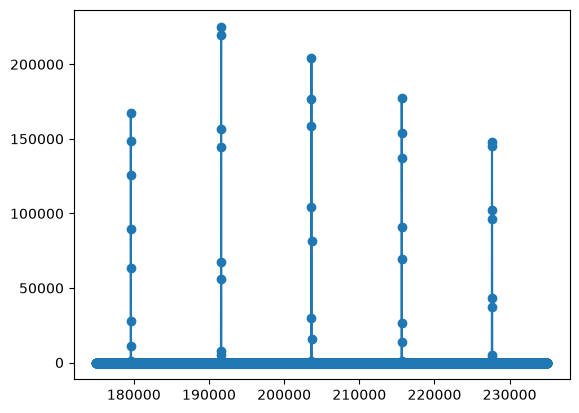

In [5]:
import numpy as np
import matplotlib.pyplot as plt

intensity = np.asarray(presample_monitor_data.Intensity, dtype=float)  # intensity in monitor
xaxis = np.asarray(presample_monitor_data.xaxis, dtype=float) 
plt.plot(xaxis, intensity, '-o')

In [6]:

with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="TOF_Sample_AllLambda_zoom"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:5, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [4.22564, 3.70791, ..., 2.92182, 2.61938]
* ki                        vector3           [1/Å]  (rrm)  [(0.00337443, -0.00398435, 1.42802), (0.00316096, -0.0037323, 1.33769), ..., (0.00280596, -0.00331313, 1.18745), (0.00265677, -0.00313697, 1.12432)]
  presample_monitor_position  vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.1796, 0.191614, ..., 0.215642, 0.227656]
* time_on_sample            float64              [s]  (rrm)  [0.1796, 0.191614, ..., 0.215642, 0.227656]
  time_on_source            float64              [s]  ()  0.0017
Data:
                            float64         [counts]  (rrm)  [635482, 881481, ..., 670269, 581267]

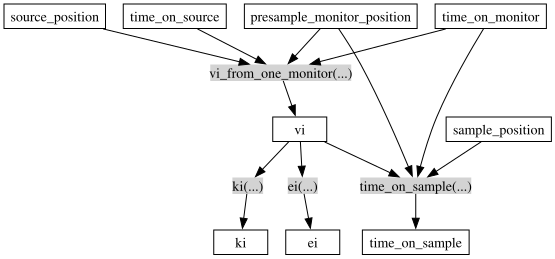

In [7]:
from dgs_reduction import calculate_ei

monitor_data.coords["time_on_source"] = sc.scalar(value=1.7, unit="ms").to(unit="s")

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [8]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
* ei                        float64            [meV]  (rrm)  [4.22564, 3.70791, ..., 2.92182, 2.61938]
* ki                        vector3           [1/Å]  (rrm)  [(0.00337443, -0.00398435, 1.42802), (0.00316096, -0.0037323, 1.33769), ..., (0.00280596, -0.00331313, 1.18745), (0.00265677, -0.00313697, 1.12432)]
* monitor_counts            float64         [counts]  (rrm)  [635482, 881481, ..., 670269, 581267]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (rrm)  [0.1796, 0.191614, ..., 0.215642, 0.227656]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.189318, 0.201989, ..., 0.227329, 0.239999]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.18284, 0.195072, ..., 0.219537, 0.23177]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [9]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:23914402, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
* toa                       float64              [s]  (events)  [0.208575, 0.183726, ..., 0.233171, 0.23318]
Data:
                            float64         [counts]  (events)  [8.64501e-06, 1.99301e-10, ..., 3.07513e-14, 0.000268959]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [10]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:23914402, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-1.65177, -2.18399, 162.804), (-1.65177, -2.18399, 162.804), ..., (3.87763, 1.29157, 159.919), (3.87763, 1.29157, 159.919)]
* ei                        float64            [meV]  (events)  [3.27983, 4.22564, ..., 2.61938, 2.61938]
* ki                        vector3           [1/Å]  (events)  [(0.0029729, -0.00351024, 1.2581), (0.00337443, -0.00398435, 1.42802), ..., (0.00265677, -0.00313697, 1.12432), (0.00265677, -0.00313697, 1.12432)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
* rrm                         int64  [dimensionless]  (events)  [2, 0, ..., 4, 4]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (events)  [0.203628, 0.1796, ..., 0.227656, 0.227656]
* toa                       float64              [s]  (events)  [0.208575, 0.183726, ..., 0.233171, 0.23318]
Data:
                            float64         [counts]  (events)  [8.64501e-06, 1.99301e-10, ..., 3.07513e-14, 0.000268959]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:23914402, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-1.65177, -2.18399, 162.804), (-1.65177, -2.18399, 162.804), ..., (3.87763, 1.29157, 159.919), (3.87763, 1.29157, 159.919)]
  ef                        float64            [meV]  (events)  [3.26209, 4.68876, ..., 2.62367, 2.61517]
  ei                        float64            [meV]  (events)  [3.27983, 4.22564, ..., 2.61938, 2.61938]
* en                        float64            [meV]  (events)  [0.0177442, -0.463127, ..., -0.00429001, 0.00421037]
* kf                        vector3           [1/Å]  (events)  [(-0.651744, -0.557971, 0.915516), (-0.781373, -0.668949, 1.09761), ..., (1.00779, 0.500446, -0.00969381), (1.00615, 0.499635, -0.00967809)]
  ki                        vector3           [1/Å]  (events)  [(0.0029729, -0.00351024, 1.2581), (0.00337443, -0.00398435, 1.42802), ..., (0.00265677, -0.00313697, 1.12432), (0.00265677, -0.00313697, 1.12432)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
  q                         vector3           [1/Å]  (events)  [(0.654717, 0.554461, 0.342583), (0.784747, 0.664965, 0.330415), ..., (-1.00513, -0.503583, 1.13401), (-1.0035, -0.502772, 1.13399)]
* q_mag                     float64           [1/Å]  (events)  [0.92382, 1.08036, ..., 1.59683, 1.59553]
* qx                        float64           [1/Å]  (events)  [0.654717, 0.784747, ..., -1.00513, -1.0035]
* qy                        float64           [1/Å]  (events)  [0.554461, 0.664965, ..., -0.503583, -0.502772]
* qz                        float64           [1/Å]  (events)  [0.342583, 0.330415, ..., 1.13401, 1.13399]
* rrm                         int64  [dimensionless]  (events)  [2, 0, ..., 4, 4]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  time_on_sample            float64              [s]  (events)  [0.203628, 0.1796, ..., 0.227656, 0.227656]
  toa                       float64              [s]  (events)  [0.208575, 0.183726, ..., 0.233171, 0.23318]
  vf                        vector3            [m/s]  (events)  [(-410.353, -351.311, 576.429), (-491.97, -421.185, 691.079), ..., (634.525, 315.092, -6.10344), (633.496, 314.581, -6.09354)]
Data:
                            float64         [counts]  (events)  [8.64501e-06, 1.99301e-10, ..., 3.07513e-14, 0.000268959]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

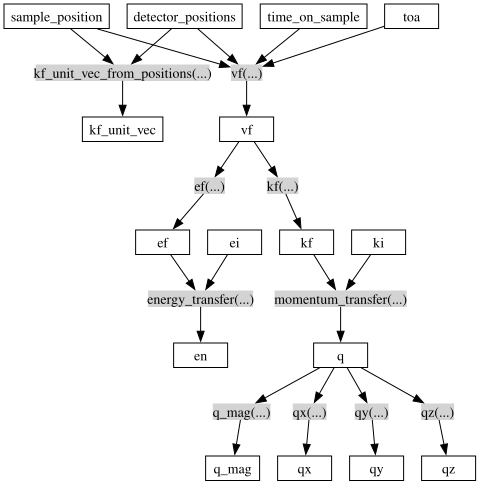

In [11]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Plot events to check for coverage
Notice here we do not ditinguish diffferent RRMs, all events are used for histogramming

In [12]:
%matplotlib widget
import plopp as pp
from dgs_reduction import generate_bins, generate_plot_coords_and_title

grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

bins = generate_bins(grid)
display(bins)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


{'qx': <scipp.Variable> (qx: 36)    float64           [1/Å]  [-2, -1.9, ..., 1.4, 1.5],
 'qy': <scipp.Variable> (qy: 41)    float64           [1/Å]  [-2, -1.9, ..., 1.9, 2],
 'qz': <scipp.Variable> (qz: 2)    float64           [1/Å]  [-1, 1],
 'en': <scipp.Variable> (en: 2)    float64            [meV]  [-0.2, 0.2]}

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:40, qz:1, en:1, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-0.2, 0.2]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1, 1]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [13]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    title=plot_title,
    vmin=0,
    vmax=1e2,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [14]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-1, 1, 0.01),
}

bins = generate_bins(grid)
plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:1, qz:1, en:200, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.99, ..., 0.99, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [15]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=50,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [17]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

parent = os.path.dirname(os.getcwd())
van_path = parent + "/runs/CSPEC_vanad_1e11"

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="ESS_Source",
        sample_name="Sample",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
sample_position = v_events_binned.coords["sample_position"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31500, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44703, 44704]
* position                  vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (3.87779, 1.29157, 159.954), (3.87763, 1.29157, 159.919)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 23914402),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44798, 44799]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 23914402),
          data=float64[counts],
          coords={'t':float64[s]})

# Mask the leakage from beamstop

In [18]:
import numpy as np

d_omega_exp = v_events.hist().data
# mask = d_omega_exp > sc.scalar(0.0015, unit=d_omega_exp.unit)
# d_omega_exp = sc.where(mask, sc.scalar(np.nan, unit=d_omega_exp.unit), d_omega_exp)

d_omega_exp /= d_omega_exp.nansum()
print(d_omega_exp)
# norm_factors.coords["d_omega_exp"] = d_omega

<scipp.Variable> (pixel_id: 44800)    float64  [dimensionless]  [2.52834e-05, 2.89517e-05, ..., 0, 0]


# Visualize the Vanadium data

In [19]:
import plopp as pp

theta_bins=320
theta_limits=[-36, 144]
y_bins=140
yheight = 3.5

nx, ny = theta_bins, y_bins
v_cylinder = sc.DataArray(
    data=sc.Variable(
        dims=["height", "two_theta"], values=np.reshape(d_omega_exp.values, (ny, nx))
    ),
    coords={
        "two_theta": sc.linspace(dim="two_theta", start=theta_limits[0], stop=theta_limits[1], num=nx),
        "height": sc.linspace(dim="height", start=-yheight/2, stop=yheight/2, num=ny),
    },
)

pp.plot(
    v_cylinder, title="Vanadium cylinder", vmin=0, vmax=1e-4, cmap="turbo", grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, ]
Coordinates:
  detector_geometry          string        <no unit>  ()  "cylinder"
  pixel_height              float64              [m]  ()  0.025
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44798, 44799]
  pixel_position            vector3              [m]  (pixel_id)  [(-2.02974, -1.7377, 2.85122), (-2.00165, -1.7377, 2.87101), ..., (2.08533, 1.73771, -2.81081), (2.05764, 1.73771, -2.83115)]
* pixel_solid_angle         float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
  pixel_width               float64              [m]  ()  0.034361
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 23914402),
          data=float64[counts],
          coords={'t':float64[s]})

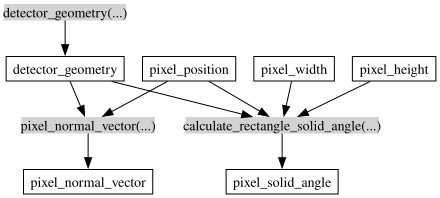

In [20]:
from reduction.dgs_reduction import calculate_solid_angle

h = sc.norm(detector_posisitions[320] - detector_posisitions[0])
w = sc.norm(detector_posisitions[1] - detector_posisitions[0])
r = detector_posisitions - sample_position

v_events.coords["pixel_position"] = r
v_events.coords["pixel_height"] = h
v_events.coords["pixel_width"] = w
v_events = v_events.transform_coords(
    [
        "pixel_solid_angle",
    ],
    graph=calculate_solid_angle,
)
display(v_events)
sc.show_graph(calculate_solid_angle)

In [21]:
pp.plot(
    {
        "McStas": d_omega_exp,
        "Calc": v_events.coords["pixel_solid_angle"]
        / sc.sum(v_events.coords["pixel_solid_angle"]),
    },
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    linestyle="-",
    markersize=2,
    #ymax=2e-5,
    ymin=0.0,
    grid=True,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [22]:
norm_factors.coords["d_omega"] = v_events.coords["pixel_solid_angle"]
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
* ei                        float64            [meV]  (rrm)  [4.22564, 3.70791, ..., 2.92182, 2.61938]
* ki                        vector3           [1/Å]  (rrm)  [(0.00337443, -0.00398435, 1.42802), (0.00316096, -0.0037323, 1.33769), ..., (0.00280596, -0.00331313, 1.18745), (0.00265677, -0.00313697, 1.12432)]
* monitor_counts            float64         [counts]  (rrm)  [635482, 881481, ..., 670269, 581267]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (rrm)  [0.1796, 0.191614, ..., 0.215642, 0.227656]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.189318, 0.201989, ..., 0.227329, 0.239999]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.18284, 0.195072, ..., 0.219537, 0.23177]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [7.60615, 6.67424, ..., 5.25928, 4.71489]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [0.845127, 0.741582, ..., 0.584364, 0.523876]
  ei                        float64            [meV]  (rrm)  [4.22564, 3.70791, ..., 2.92182, 2.61938]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.995203, -0.852013, 1.39798), (-0.932245, -0.798114, 1.30954), ..., (0.838919, 0.70848, -1.15429), (0.794314, 0.670811, -1.09292)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [1.91591, 1.7947, ..., 1.59314, 1.50844]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.331734, -0.284004, 0.465993), (-0.310748, -0.266038, 0.436514), ..., (0.27964, 0.23616, -0.384763), (0.264771, 0.223604, -0.364305)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [0.638636, 0.598235, ..., 0.531048, 0.502813]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.519442, -0.444705, 0.72967), (-0.512254, -0.444704, 0.734734), ..., (0.533668, 0.444706, -0.719329), (0.52658, 0.444705, -0.724534)]
  ki                        vector3           [1/Å]  (rrm)  [(0.00337443, -0.00398435, 1.42802), (0.00316096, -0.0037323, 1.33769), ..., (0.00280596, -0.00331313, 1.18745), (0.00265677, -0.00313697, 1.12432)]
* monitor_counts            float64         [counts]  (rrm)  [635482, 881481, ..., 670269, 581267]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(0.998577, 0.848028, 0.0300443), (0.935406, 0.794381, 0.0281436), ..., (-0.836113, -0.711793, 2.34174), (-0.791658, -0.673948, 2.21723)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(0.335109, 0.28002, 0.96203), (0.313909, 0.262306, 0.901171), ..., (-0.276834, -0.239473, 1.57221), (-0.262115, -0.226741, 1.48862)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  time_on_sample            float64              [s]  (rrm)  [0.1796, 0.191614, ..., 0.215642, 0.227656]
  toa_max                   float64              [s]  (pixel_id, rrm)  [0.189318, 0.201989, ..., 0.227329, 0.239999]
  toa_min                   float64              [s]  (pixel_id, rrm)  [0.18284, 0.195072, ..., 0.219537, 0.23177]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

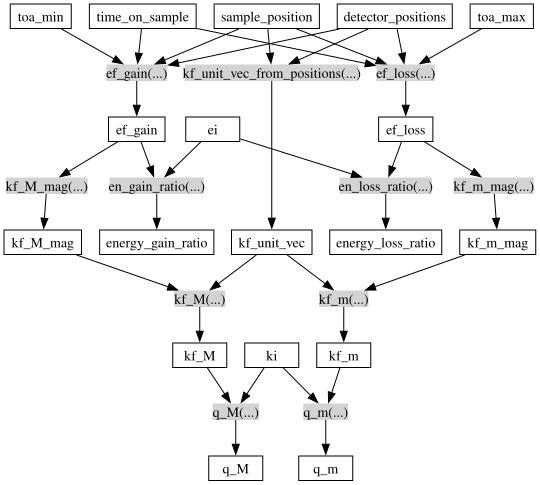

In [23]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

In [24]:
from dgs_reduction import mdnorm

grid = {
    "qx": (-3, 3, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

rrm = 0
data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [25]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [26]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [27]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [28]:
grid = {
    "qx": (-3, 1.5, 0.02),
    "qy": (-0.02, 0.02),
    "qz": (-1, 3.0, 0.02),
    "en": (-0.2, 0.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [29]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [30]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-0.1, 0.1),
    "qz": (-1, 3.0, 0.1),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(
    events,
    grid,
    norm_factors,
    rrm=rrm,
)

In [31]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# averaging over a large Q ranges is very slow

In [32]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5, 0.1),
    "en": (-10, 10, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [33]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot a 1D cut

In [34]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [35]:
data

<scipp.DataArray>
Dimensions: Sizes[en:400, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.98, ..., 3.98, 4]
  qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
  qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
  qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
Data:
                            float64       [1/sr/meV]  (en)  [nan, nan, ..., nan, nan]

In [36]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [37]:
grid = {
    "qx": (-2.5, 2.0, 0.05),
    "qy": (-1.0, 1.0),
    "qz": (-0.0, 1.0),
    "en": (-1.5, 0.5, 0.005),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [38]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot |Q| vs. E for powder samples

In [39]:
grid = {
    "qx": (-3, 3.0, 0.1),
    "qy": (-3.0, 3.0, 0.1),
    "qz": (-3, 3, 0.1),
    "en": (-4, 4, 0.005),
}

data4d, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

mag_q = sc.sqrt(
    sc.midpoints(data4d.coords["qx"]) ** 2
    + sc.midpoints(data4d.coords["qy"]) ** 2
    + sc.midpoints(data4d.coords["qz"]) ** 2
)

data4d.coords["mag_q"] = mag_q
data4d

<scipp.DataArray>
Dimensions: Sizes[en:1600, qz:60, qy:60, qx:60, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (qx, qy, qz)  [5.10955, 5.05247, ..., 5.05247, 5.10955]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-3, -2.9, ..., 2.9, 3]
Data:
                            float64       [1/sr/meV]  (en, qz, qy, qx)  [nan, nan, ..., nan, nan]

In [41]:
q_bins = sc.linspace("mag_q", 0.0, 4.0, num=100, unit="1/Å")
rebinned = data4d.bin(mag_q=q_bins)
data_rebinned = rebinned.bins.nanmean()
display(data_rebinned)

pp.plot(
    data_rebinned,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

<scipp.DataArray>
Dimensions: Sizes[en:1600, mag_q:99, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (mag_q [bin-edge])  [0, 0.040404, ..., 3.9596, 4]
Data:
                            float64       [1/sr/meV]  (en, mag_q)  [nan, nan, ..., nan, nan]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…